In [4]:
!pip install opencv-python-headless dlib

Please upload an image with faces...


Saving IMG-20230501-WA0026.jpg to IMG-20230501-WA0026.jpg
Image uploaded: IMG-20230501-WA0026.jpg

Total faces detected: 10


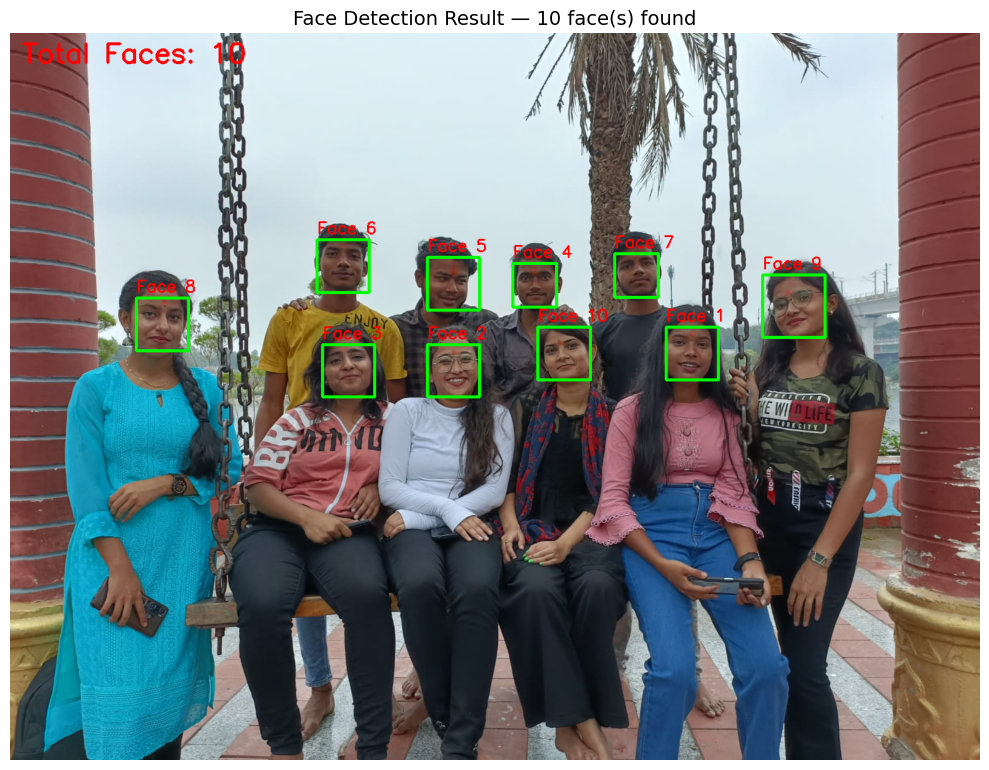


Done! 10 face(s) detected.
Result saved as face_result.jpg


In [6]:
# ============================================
# Upload an image → detects & counts faces
# ============================================

# First install libraries:
# !pip install opencv-python-headless dlib

import cv2
import dlib
import numpy as np
from google.colab import files
from IPython.display import display, Image
import matplotlib.pyplot as plt

# ── STEP 1: Upload your image ───────────────

print("Please upload an image with faces...")
uploaded = files.upload()

# Get the filename of uploaded image
filename = list(uploaded.keys())[0]
print(f"Image uploaded: {filename}")

# ── STEP 2: Load the image ──────────────────

img = cv2.imread(filename)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # convert for display

# ── STEP 3: Load face detector ──────────────

detector = dlib.get_frontal_face_detector()

# Convert to grayscale for detection
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ── STEP 4: Detect faces ────────────────────

faces = detector(gray)
face_count = len(faces)
print(f"\nTotal faces detected: {face_count}")

# ── STEP 5: Draw boxes around faces ─────────

result = img_rgb.copy()

for i, face in enumerate(faces):
    x  = face.left()
    y  = face.top()
    x1 = face.right()
    y1 = face.bottom()

    # Green rectangle around face
    cv2.rectangle(result, (x, y), (x1, y1), (0, 255, 0), 3)

    # Label each face
    cv2.putText(result, f'Face {i+1}',
                (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.9, (255, 0, 0), 2)

# Show total count on image
cv2.putText(result, f'Total Faces: {face_count}',
            (20, 50),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.5, (255, 0, 0), 3)

# ── STEP 6: Display the result ──────────────

plt.figure(figsize=(10, 8))
plt.imshow(result)
plt.title(f'Face Detection Result — {face_count} face(s) found', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig('face_result.jpg')
plt.show()

print(f"\nDone! {face_count} face(s) detected.")
print("Result saved as face_result.jpg")